In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

df = pd.read_csv("insurance.csv")

In [ ]:
UNIVARIATE ANALYSIS

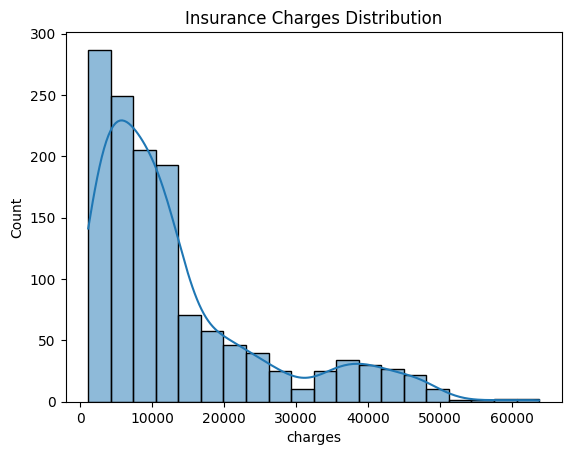

In [44]:
plt.figure()
sns.histplot(df['charges'], bins=20, kde=True)
plt.title("Insurance Charges Distribution")
plt.show()

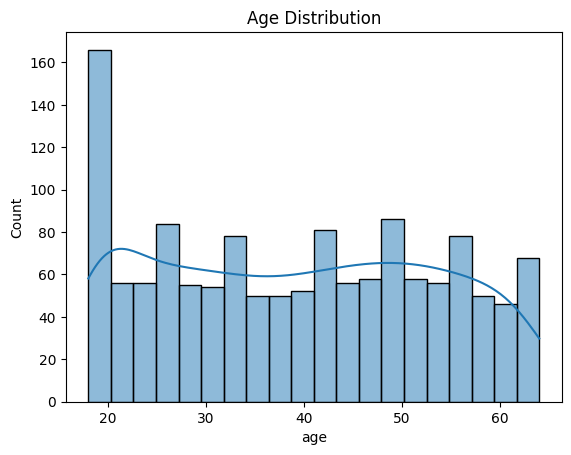

In [45]:
plt.figure()
sns.histplot(df['age'], bins=20, kde=True)
plt.title("Age Distribution")
plt.show()

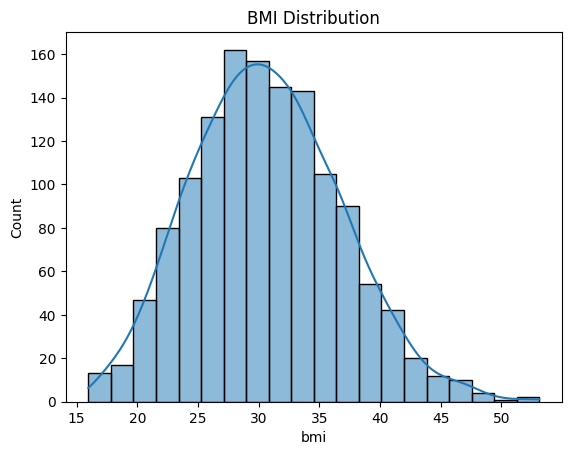

In [14]:
plt.figure()
sns.histplot(df['bmi'], bins=20, kde=True)
plt.title("BMI Distribution")
plt.show()

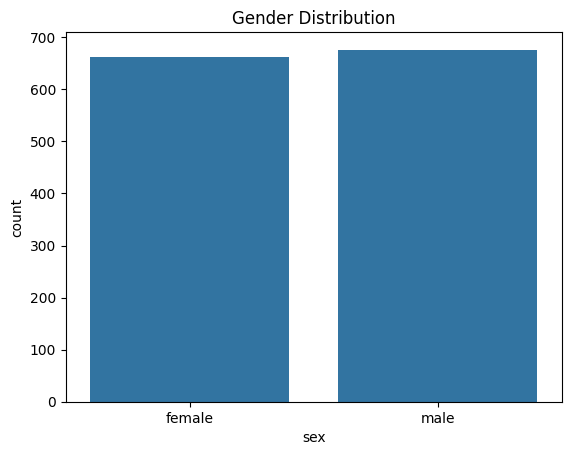

In [16]:
plt.figure()
sns.countplot(x='sex', data=df)
plt.title("Gender Distribution")
plt.show()

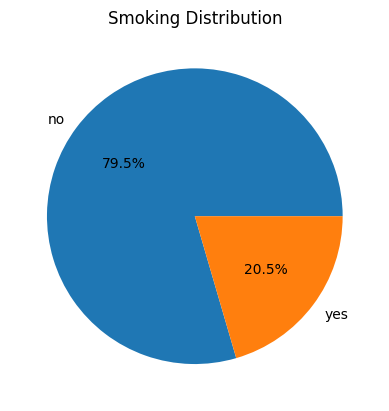

In [41]:
plt.figure()

smoker_counts = df['smoker'].value_counts()

plt.pie(smoker_counts.values, 
        labels=smoker_counts.index, 
        autopct='%1.1f%%')

plt.title("Smoking Distribution")
plt.show()

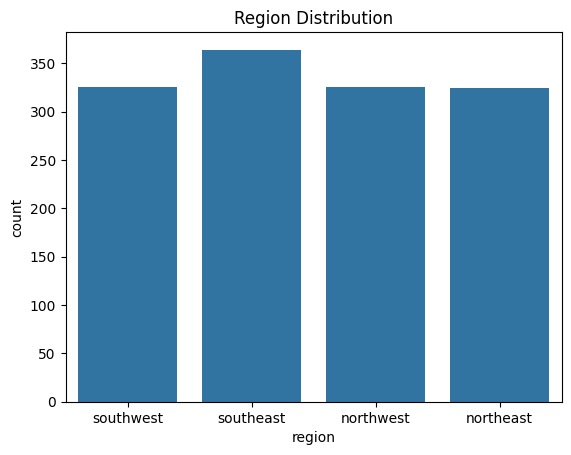

In [18]:
plt.figure()
sns.countplot(x='region', data=df)
plt.title("Region Distribution")
plt.show()

In [ ]:
BIVARIATE ANALYSIS

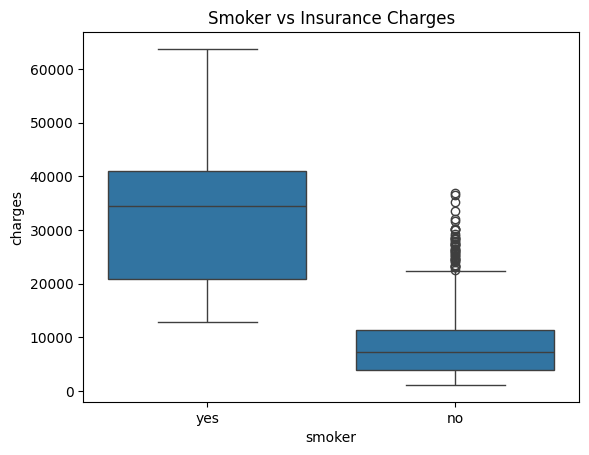

In [19]:
plt.figure()
sns.boxplot(x='smoker', y='charges', data=df)
plt.title("Smoker vs Insurance Charges")
plt.show()

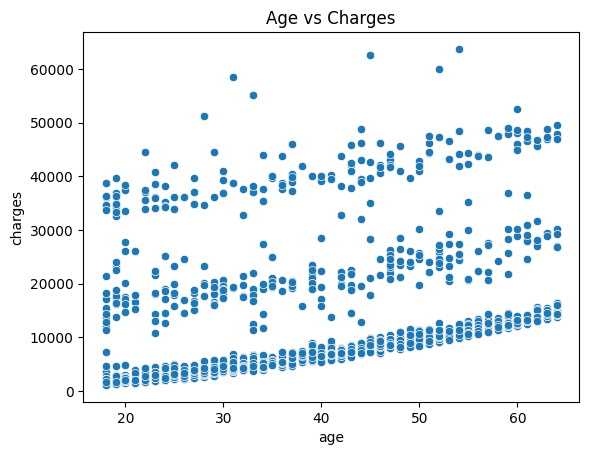

In [20]:
plt.figure()
sns.scatterplot(x='age', y='charges', data=df)
plt.title("Age vs Charges")
plt.show()

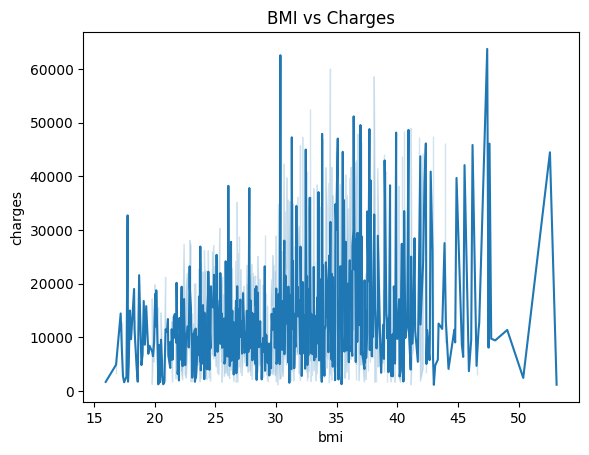

In [22]:
plt.figure()
sns.lineplot(x='bmi', y='charges', data=df)
plt.title("BMI vs Charges")
plt.show()

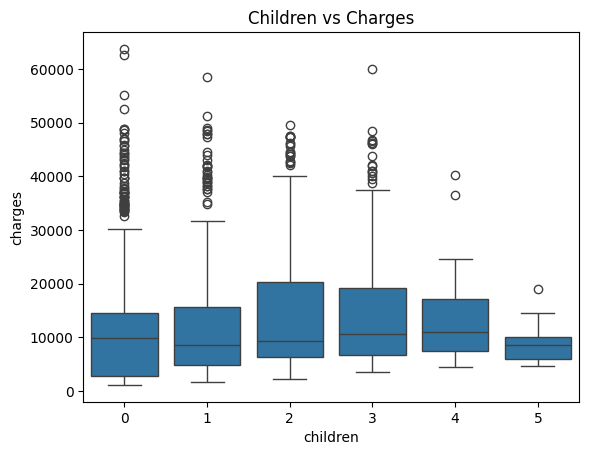

In [23]:
plt.figure()
sns.boxplot(x='children', y='charges', data=df)
plt.title("Children vs Charges")
plt.show()

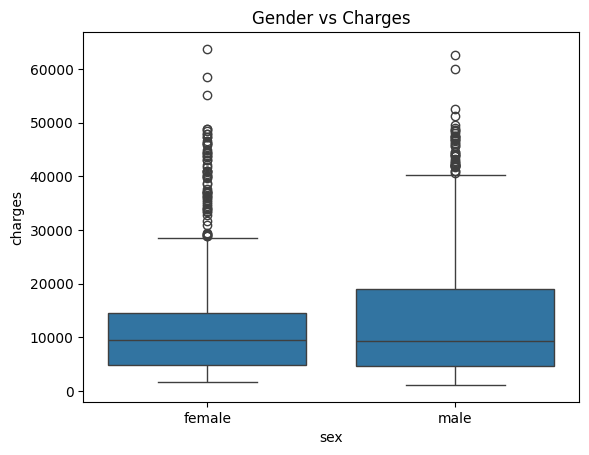

In [24]:
plt.figure()
sns.boxplot(x='sex', y='charges', data=df)
plt.title("Gender vs Charges")
plt.show()

In [ ]:
MULTIVARIATE ANALYSIS

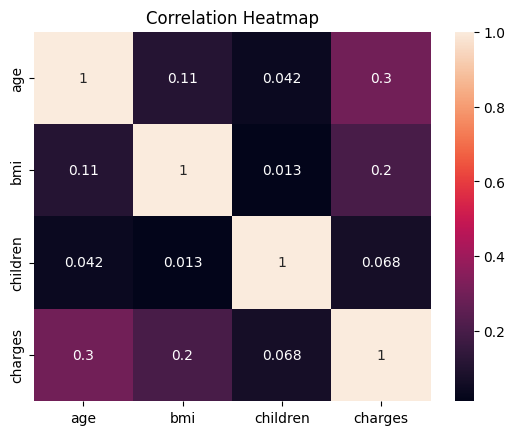

In [25]:
plt.figure()
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Heatmap")
plt.show()

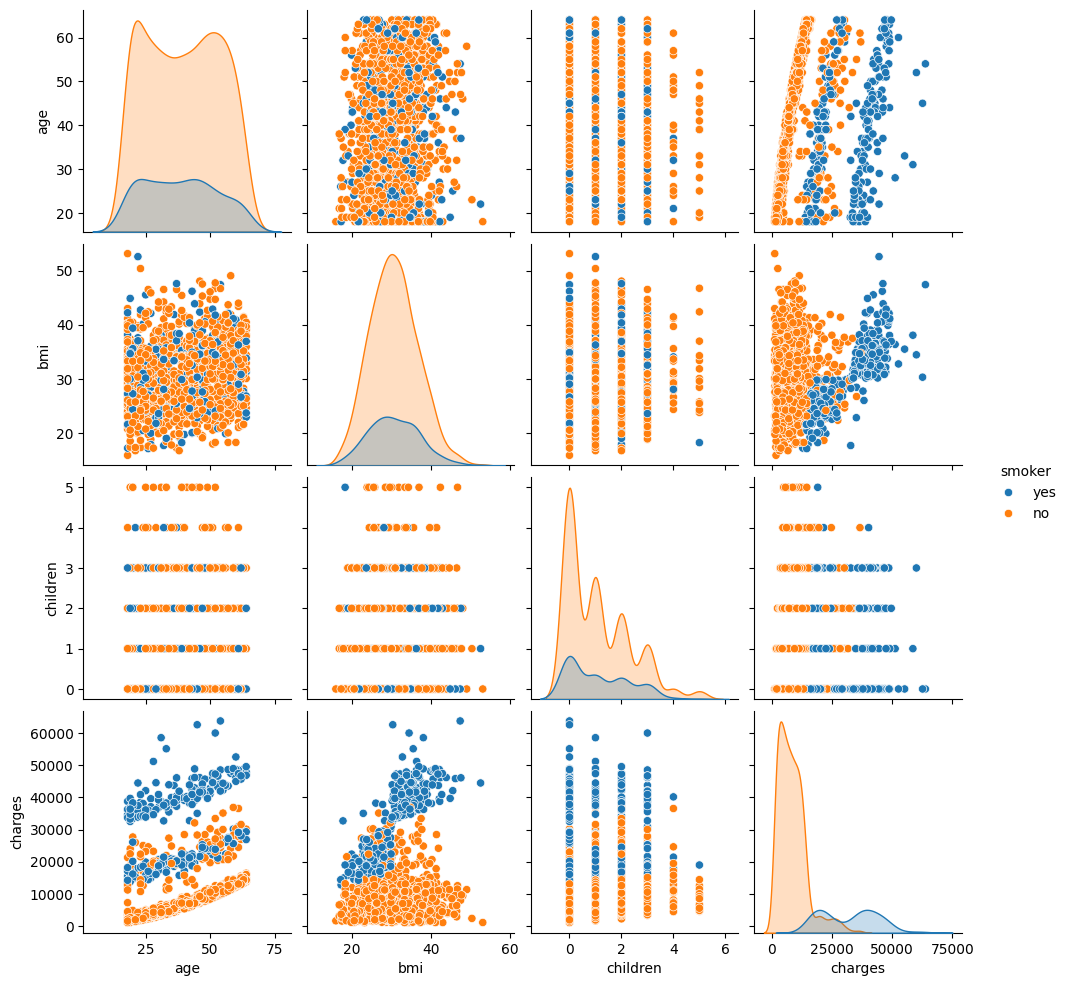

In [26]:
sns.pairplot(df, hue='smoker')
plt.show()

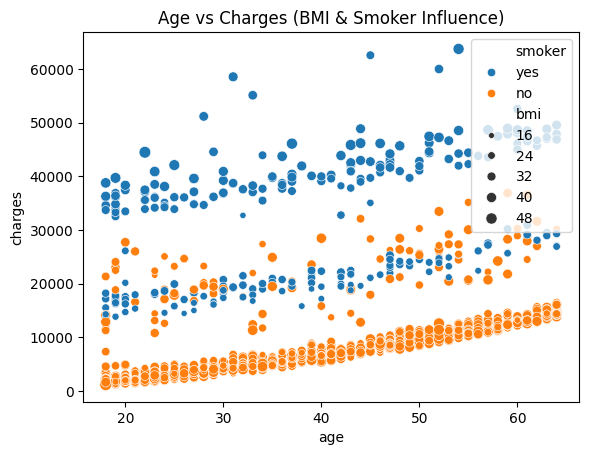

In [27]:
plt.figure()
sns.scatterplot(x='age', y='charges', hue='smoker', size='bmi', data=df)
plt.title("Age vs Charges (BMI & Smoker Influence)")
plt.show()

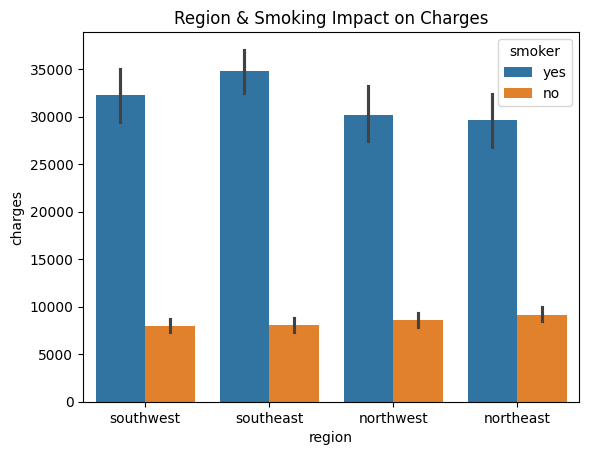

In [28]:
plt.figure()
sns.barplot(x='region', y='charges', hue='smoker', data=df)
plt.title("Region & Smoking Impact on Charges")
plt.show()

In [31]:
# ML Model + Metrics

In [32]:
# Create a new column: High cost (1) / Low cost (0)
threshold = df['charges'].median()

df['high_cost'] = (df['charges'] > threshold).astype(int)

In [33]:
df_encoded = pd.get_dummies(df, columns=['sex', 'smoker', 'region'], drop_first=True)

In [34]:
X = df_encoded.drop(['charges', 'high_cost'], axis=1)
y = df_encoded['high_cost']

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [36]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [37]:
y_pred = model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9104477611940298
Precision: 0.8828125
Recall: 0.9262295081967213
F1 Score: 0.904


In [39]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [accuracy, precision, recall, f1]
})

print(metrics_df)

      Metric     Value
0   Accuracy  0.910448
1  Precision  0.882812
2     Recall  0.926230
3   F1 Score  0.904000


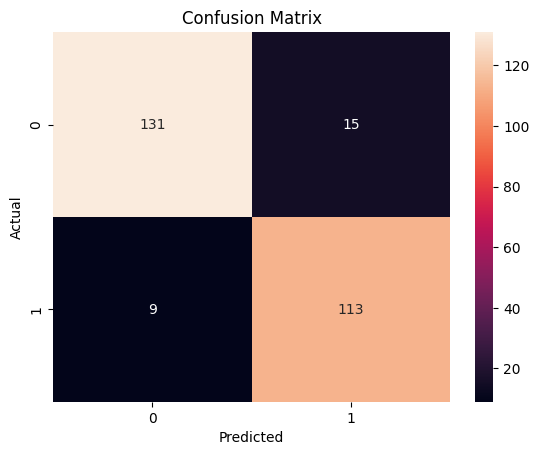

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [46]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.90      0.92       146
           1       0.88      0.93      0.90       122

    accuracy                           0.91       268
   macro avg       0.91      0.91      0.91       268
weighted avg       0.91      0.91      0.91       268



In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score'],
    'Value': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})

print(metrics_df)

      Metric     Value
0   Accuracy  0.910448
1  Precision  0.882812
2     Recall  0.926230
3   F1 Score  0.904000


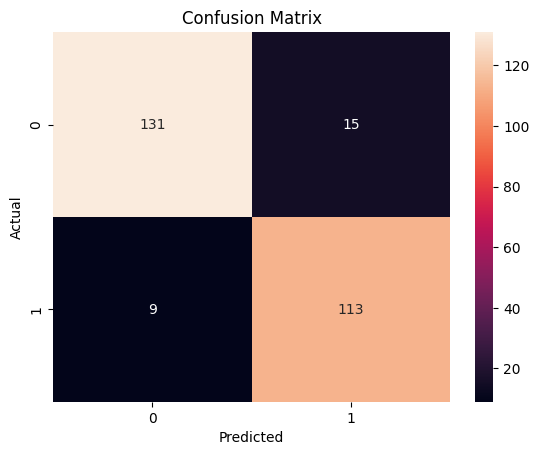

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
errors = X_test.copy()
errors['Actual'] = y_test
errors['Predicted'] = y_pred

wrong_predictions = errors[errors['Actual'] != errors['Predicted']]

print(wrong_predictions.head())

      age     bmi  children  sex_male  smoker_yes  region_northwest  \
764    45  25.175         2     False       False             False   
429    27  30.400         3     False       False              True   
1253   40  29.300         4     False       False             False   
777    45  39.805         0      True       False             False   
806    40  41.420         1     False       False              True   

      region_southeast  region_southwest  Actual  Predicted  
764              False             False       0          1  
429              False             False       1          0  
1253             False              True       1          0  
777              False             False       0          1  
806              False             False       1          0  


In [50]:
print(wrong_predictions.describe())

             age        bmi   children     Actual  Predicted
count  24.000000  24.000000  24.000000  24.000000  24.000000
mean   40.958333  31.840417   0.875000   0.375000   0.625000
std    10.703430   6.152851   1.075922   0.494535   0.494535
min    19.000000  21.300000   0.000000   0.000000   0.000000
25%    32.000000  27.441250   0.000000   0.000000   0.000000
50%    46.000000  30.215000   1.000000   0.000000   1.000000
75%    49.000000  35.646250   1.000000   1.000000   1.000000
max    51.000000  45.320000   4.000000   1.000000   1.000000


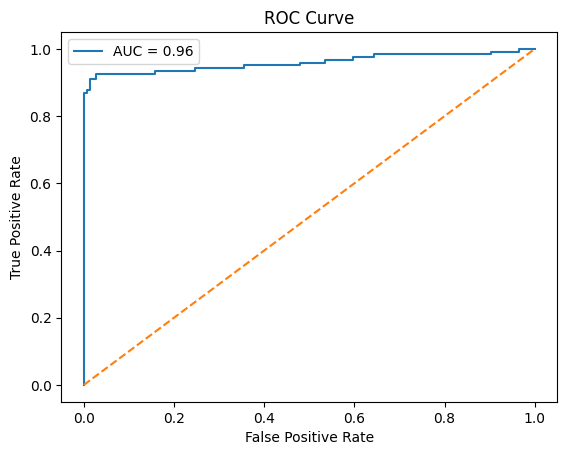

In [51]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()